# GPU

In [ ]:
!pip install sentence-transformers transformers sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 15.5 MB/s eta 0:00:00


In [ ]:
# =========================================
# OPTIMIZED NOTEBOOK FOR 180K DATASET
# =========================================



import pandas as pd
import re
import torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
from transformers import MarianMTModel, MarianTokenizer


In [ ]:

# ================================
# 1. Load dataset
# ================================
df = pd.read_csv('/content/bilingual_part_1.csv')
print(f"Original dataset: {len(df)} rows")

# ================================
# 2. Basic filtering (FAST)
# ================================
df['en_len'] = df['en'].apply(lambda x: len(str(x).split()))
df['vi_len'] = df['vi'].apply(lambda x: len(str(x).split()))
df['len_ratio'] = df['vi_len'] / df['en_len']

# filter nhanh
df = df[(df['len_ratio'] > 0.3) & (df['len_ratio'] < 3)]

# ================================
# 3. Abbreviation check (FAST)
# ================================
def extract_abbr(text):
    return re.findall(r'\b[A-Z]{2,}\b', str(text))

def has_missing_abbr(row):
    en_abbrs = extract_abbr(row['en'])
    return any(abbr not in row['vi'] for abbr in en_abbrs)

df = df[~df.apply(has_missing_abbr, axis=1)]

print(f"After fast filtering: {len(df)} rows")

# ================================
# 4. Load models (GPU nếu có)
# ================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Embedding model
embed_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# MarianMT: Vietnamese -> English
model_name = "Helsinki-NLP/opus-mt-vi-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
mt_model = MarianMTModel.from_pretrained(model_name).to(device)

# ================================
# 5. Batch back-translation
# ================================
def translate_batch(texts, batch_size=32):
    outputs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)
        translated = mt_model.generate(**inputs)
        decoded = [tokenizer.decode(t, skip_special_tokens=True) for t in translated]
        outputs.extend(decoded)
    return outputs

# ================================
# 6. Compute similarity in batches
# ================================
batch_size = 512
threshold = 0.7

keep_indices = []

for i in tqdm(range(0, len(df), batch_size)):
    batch_df = df.iloc[i:i+batch_size]

    en_texts = batch_df['en'].tolist()
    vi_texts = batch_df['vi'].tolist()

    # Back translate
    vi2en = translate_batch(vi_texts, batch_size=32)

    # Embeddings
    en_emb = embed_model.encode(en_texts, convert_to_tensor=True)
    bt_emb = embed_model.encode(vi2en, convert_to_tensor=True)

    sim = util.cos_sim(en_emb, bt_emb).diagonal().cpu().numpy()

    # Giữ lại câu tốt
    for idx, s in zip(batch_df.index, sim):
        if s >= threshold:
            keep_indices.append(idx)

print(f"Kept rows after semantic filtering: {len(keep_indices)}")

# ================================
# 7. Save clean dataset
# ================================
df_clean = df.loc[keep_indices].reset_index(drop=True)

df_clean.to_csv('bilingual_dataset_clean_180k.csv', index=False)

print("Saved: bilingual_dataset_clean_180k.csv")

Original dataset: 34323 rows
After fast filtering: 31892 rows


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/289M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

100%|██████████| 63/63 [1:39:04<00:00, 94.36s/it]


Kept rows after semantic filtering: 20467
Saved: bilingual_dataset_clean_180k.csv


In [ ]:
from google.colab import files
files.download("/content/bilingual_dataset_clean_180k.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

files = [
    'bilingual_dataset_clean_180k_part1.csv',
    'bilingual_dataset_clean_180k_part2.csv',
    'bilingual_dataset_clean_180k_part3.csv',
    'bilingual_dataset_clean_180k_part4.csv',
    'bilingual_dataset_clean_180k_part5.csv'
]

dfs = []

for file in files:
    df = pd.read_csv(file)

    # Chỉ giữ 2 cột cần thiết
    df = df[['en', 'vi', 'domain']]


    dfs.append(df)

# Gộp lại
final_df = pd.concat(dfs, ignore_index=True)

# Lưu file
final_df.to_csv('bilingual_merged.csv', index=False)

print(f"Saved: bilingual_merged.csv ({len(final_df)} rows)")

Saved: bilingual_merged.csv (102616 rows)


In [ ]:
from google.colab import files
files.download("/content/bilingual_merged.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

domain
general     31176
medical     25384
it          24956
business    21100
Name: count, dtype: int64


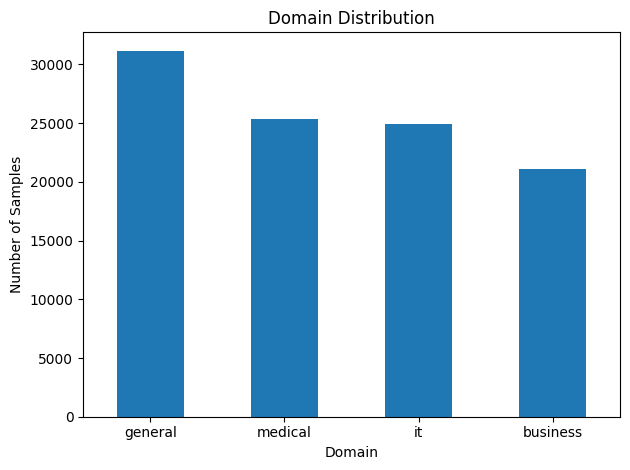

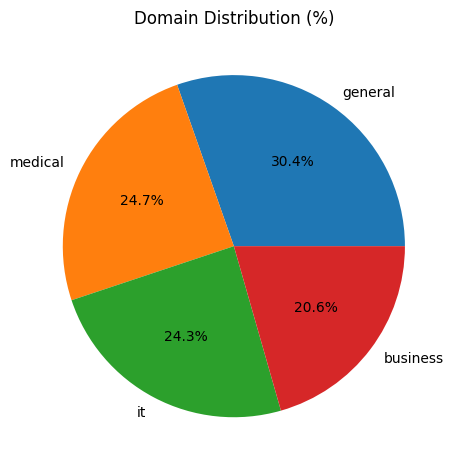

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dữ liệu
df = pd.read_csv('bilingual_merged.csv')

# Đếm số lượng mỗi domain
domain_counts = df['domain'].value_counts()

print(domain_counts)

# ---------------------------------
# 1. Bar chart
# ---------------------------------
plt.figure()
domain_counts.plot(kind='bar')

plt.title('Domain Distribution')
plt.xlabel('Domain')
plt.ylabel('Number of Samples')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------
# 2. Pie chart (tuỳ chọn)
# ---------------------------------
plt.figure()
domain_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title('Domain Distribution (%)')
plt.ylabel('')  # bỏ label trục y

plt.tight_layout()
plt.show()

In [ ]:
domain_counts

,count
domain,
general,31176
medical,25384
it,24956
business,21100
